# Dense HyDE vs original-query RRF fusion sweep

Weighted RRF over paired dense runs (HyDE query vs original query), sweep weights, report **mean Recall@5000** (same definition as `retrieval_eval.common.recall_at_k`). One figure per dataset.

In [15]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

_shared = base_dir / "scripts" / "public" / "shared_scripts"
if str(_shared) not in sys.path:
    sys.path.insert(0, str(_shared))

from retrieval_eval.common import recall_at_k

output_dir = base_dir / "output" / "retrieval_test" / "dense_hyde_fusion_sweep"
output_dir.mkdir(parents=True, exist_ok=True)

print("base_dir:", base_dir)
print("figures:", output_dir)

base_dir: /Users/yun/develop/BioASQ
figures: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep


In [16]:
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {_extract_pmid(d) for d in docs if _extract_pmid(d)}
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    return {
        str(qid): grp[doc_col].astype(str).tolist()
        for qid, grp in run_df.groupby(qid_col, sort=False)
    }


def _rrf_fuse_two_lists(
    docs_a: list[str],
    docs_b: list[str],
    pool_a: int,
    pool_b: int,
    k_rrf: int,
    w_a: float,
    w_b: float,
) -> list[str]:
    a_top = docs_a[:pool_a]
    b_top = docs_b[:pool_b]
    rank_a = {d: i + 1 for i, d in enumerate(a_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    union = list(dict.fromkeys(a_top + b_top))
    scored = []
    for d in union:
        s = 0.0
        ra = rank_a.get(d)
        rb = rank_b.get(d)
        if ra is not None:
            s += w_a / (k_rrf + ra)
        if rb is not None:
            s += w_b / (k_rrf + rb)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


def mean_recall_at_k_fused(
    gold: dict[str, set[str]],
    run_hyde: dict[str, list[str]],
    run_orig: dict[str, list[str]],
    *,
    k_rrf: int,
    w_hyde: float,
    w_orig: float,
    pool_top: int,
    k_eval: int,
) -> tuple[float, int]:
    qids = [q for q in gold if q in run_hyde and q in run_orig and gold[q]]
    if not qids:
        return 0.0, 0
    recalls: list[float] = []
    for q in qids:
        docs_h = run_hyde[q]
        docs_o = run_orig[q]
        pool_h = min(pool_top, len(docs_h)) if docs_h else 0
        pool_o = min(pool_top, len(docs_o)) if docs_o else 0
        fused = _rrf_fuse_two_lists(
            docs_h,
            docs_o,
            pool_h,
            pool_o,
            k_rrf=k_rrf,
            w_a=w_hyde,
            w_b=w_orig,
        )
        fused = fused[:k_eval]
        recalls.append(recall_at_k(set(gold[q]), fused, k_eval))
    return float(np.mean(recalls)) if recalls else 0.0, len(qids)

In [17]:
RUN_POOL_TOP = 5000
K_EVAL = 5000
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]

split_labels = {
    "training14b_3pct_sample": "training14b_3pct (dev sample)",
    "13b_golden_50q_sample": "13b golden 50q",
    "BioASQ-task14bPhaseB-testset1": "14b Phase B testset1",
}

DATASETS: list[dict] = [
    {
        "split": "training14b_3pct_sample",
        "hyde_tsv": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense"
        / "runs"
        / "dense_training14b_3pct_sample.tsv",
        "orig_tsv": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense_"
        / "runs"
        / "dense_training14b_3pct_sample.tsv",
        "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
    },
    {
        "split": "13b_golden_50q_sample",
        "hyde_tsv": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense"
        / "runs"
        / "dense_13b_golden_50q_sample.tsv",
        "orig_tsv": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense_"
        / "runs"
        / "dense_13b_golden_50q_sample.tsv",
        "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
    },
    {
        "split": "BioASQ-task14bPhaseB-testset1",
        "hyde_tsv": base_dir
        / "output"
        / "retrieval_test"
        / "hyde"
        / "dense"
        / "runs"
        / "dense_BioASQ-task14bPhaseB-testset1.tsv",
        "orig_tsv": base_dir
        / "bioasq14_output"
        / "batch_1"
        / "dense"
        / "runs"
        / "dense_BioASQ-task14bPhaseB-testset1.tsv",
        "qrels_path": base_dir / "bioasq_data" / "14b" / "BioASQ-task14bPhaseB-testset1",
    },
]

In [18]:
rrf_rows: list[dict] = []

for spec in DATASETS:
    split = spec["split"]
    p_h = spec["hyde_tsv"]
    p_o = spec["orig_tsv"]
    p_q = spec["qrels_path"]
    for path, label in [(p_h, "hyde"), (p_o, "orig")]:
        if not path.exists():
            raise FileNotFoundError(f"Missing {label} run: {path}")
    if not p_q.exists():
        raise FileNotFoundError(f"Missing qrels: {p_q}")

    gold = _load_qrels(p_q)
    df_h = _load_run(p_h)
    df_o = _load_run(p_o)
    run_hyde = _build_run_map(df_h)
    run_orig = _build_run_map(df_o)

    for k_rrf in RRF_KS:
        for w_hyde, w_orig in RRF_WEIGHTS:
            mean_r, n_q = mean_recall_at_k_fused(
                gold,
                run_hyde,
                run_orig,
                k_rrf=k_rrf,
                w_hyde=w_hyde,
                w_orig=w_orig,
                pool_top=RUN_POOL_TOP,
                k_eval=K_EVAL,
            )
            rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hyde": w_hyde,
                    "w_orig": w_orig,
                    "MeanR@5000": mean_r,
                    "n_queries": n_q,
                }
            )

rrf_results = pd.DataFrame(rrf_rows)
rrf_results["weight_label"] = rrf_results.apply(
    lambda r: f"({r['w_hyde']:.1f},{r['w_orig']:.1f})",
    axis=1,
)
weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

csv_path = output_dir / "dense_hyde_rrf_sweep_meanr5000.csv"
rrf_results.to_csv(csv_path, index=False)
print("Saved:", csv_path)
rrf_results.head(12)

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_hyde_rrf_sweep_meanr5000.csv


,split,k_rrf,w_hyde,w_orig,MeanR@5000,n_queries,weight_label
0,training14b_3pct_sample,60,1.0,0.0,0.902202,192,"(1.0,0.0)"
1,training14b_3pct_sample,60,0.9,0.1,0.902804,192,"(0.9,0.1)"
2,training14b_3pct_sample,60,0.8,0.2,0.898435,192,"(0.8,0.2)"
3,training14b_3pct_sample,60,0.7,0.3,0.898386,192,"(0.7,0.3)"
4,training14b_3pct_sample,60,0.6,0.4,0.899936,192,"(0.6,0.4)"
5,training14b_3pct_sample,60,0.5,0.5,0.896492,192,"(0.5,0.5)"
6,training14b_3pct_sample,60,0.4,0.6,0.895400,192,"(0.4,0.6)"
7,training14b_3pct_sample,60,0.3,0.7,0.893325,192,"(0.3,0.7)"
8,training14b_3pct_sample,60,0.2,0.8,0.884838,192,"(0.2,0.8)"
9,training14b_3pct_sample,60,0.1,0.9,0.878312,192,"(0.1,0.9)"


In [19]:
best_rows = []
for split, grp in rrf_results.groupby("split", sort=False):
    idx = grp["MeanR@5000"].idxmax()
    best_rows.append(rrf_results.loc[idx])
best_df = pd.DataFrame(best_rows).reset_index(drop=True)
print("Best weight per dataset (max MeanR@5000):")
print(best_df.to_string(index=False))

Best weight per dataset (max MeanR@5000):
                        split  k_rrf  w_hyde  w_orig  MeanR@5000  n_queries weight_label
      training14b_3pct_sample     60     0.9     0.1    0.902804        192    (0.9,0.1)
        13b_golden_50q_sample     60     0.5     0.5    0.949163         50    (0.5,0.5)
BioASQ-task14bPhaseB-testset1     60     0.8     0.2    0.789174         80    (0.8,0.2)


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_hyde_rrf_meanr5000_vs_weight_training14b_3pct_sample.png


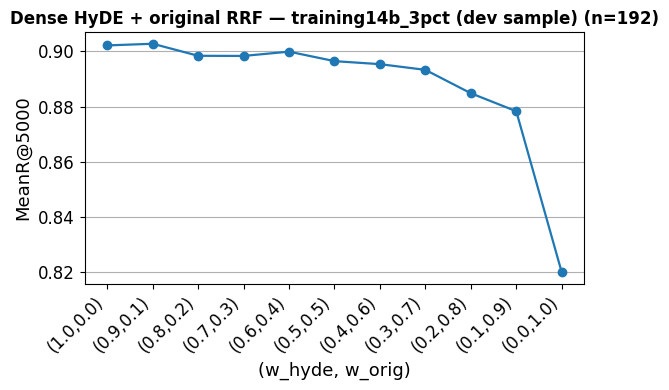

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_hyde_rrf_meanr5000_vs_weight_13b_golden_50q_sample.png


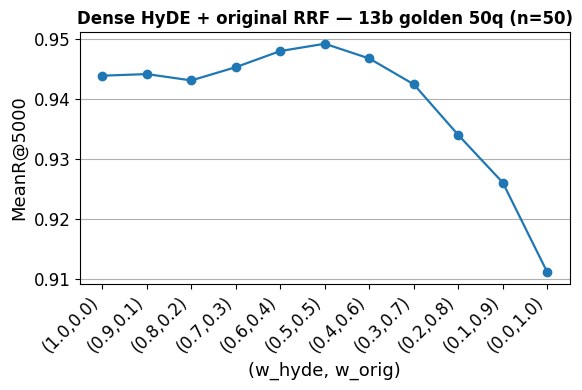

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_hyde_rrf_meanr5000_vs_weight_BioASQ-task14bPhaseB-testset1.png


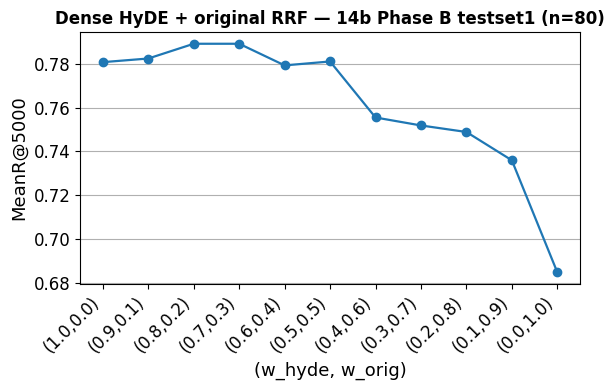

In [20]:
for split, grp in rrf_results.groupby("split", sort=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    for k_rrf in sorted(grp["k_rrf"].unique()):
        sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
        vals = sub["MeanR@5000"].values
        ax.plot(
            range(len(weight_order)),
            vals,
            marker="o",
            linewidth=1.6,
            label=f"k_rrf={k_rrf}",
        )
    ax.set_xticks(range(len(weight_order)))
    ax.set_xticklabels(weight_order, rotation=45, ha="right")
    n_q = int(grp["n_queries"].max())
    title = split_labels.get(split, split)
    ax.set_title(
        f"Dense HyDE + original RRF — {title} (n={n_q})",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("MeanR@5000")
    ax.set_xlabel("(w_hyde, w_orig)")
    ax.grid(True, axis="y")
    if len(RRF_KS) > 1:
        ax.legend()
    plt.tight_layout()
    safe = split.replace(" ", "_").replace("/", "_")
    fig_path = output_dir / f"dense_hyde_rrf_meanr5000_vs_weight_{safe}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()